# 04 — SHAP Analysis & Model Explainability
**Project:** Student Performance Predictor  
**Goal:** Understand which features drive the model's predictions 
and explain why individual students are flagged as at-risk.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

In [18]:
model = joblib.load("../models/xgb_model.pkl")
df = pd.read_csv("../data/processed/merged.csv")

In [19]:
df

,code_module,code_presentation,id_student,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,at_risk,region_East Anglian Region,...,region_West Midlands Region,region_Yorkshire Region,mean_score,max_score,min_score,number_of_takes,mean_weight,total_clicks,num_active_days,avg_daily_clicks
0,AAA,2013J,11391,3,9,2,0,240,0,True,...,False,False,81.5,85.0,78.0,2.0,15.0,587.0,23.0,26.0
1,AAA,2013J,28400,3,2,1,0,60,0,False,...,False,False,69.0,70.0,68.0,2.0,15.0,821.0,36.0,23.0
2,AAA,2013J,30268,2,3,1,0,60,1,False,...,False,False,0.0,0.0,0.0,0.0,0.0,281.0,12.0,23.0
3,AAA,2013J,31604,2,5,1,0,60,0,False,...,False,False,71.5,72.0,71.0,2.0,15.0,992.0,51.0,19.0
4,AAA,2013J,32885,1,5,0,0,60,0,False,...,True,False,49.5,69.0,30.0,2.0,15.0,684.0,35.0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,1,1,0,0,30,1,False,...,False,False,0.0,0.0,0.0,0.0,0.0,41.0,5.0,8.0
32589,GGG,2014J,2645731,1,4,1,0,30,0,True,...,False,False,80.0,80.0,80.0,1.0,0.0,81.0,8.0,10.0
32590,GGG,2014J,2648187,2,2,0,0,30,0,False,...,False,False,65.0,65.0,65.0,1.0,0.0,35.0,5.0,7.0
32591,GGG,2014J,2679821,1,9,1,0,30,1,False,...,False,False,83.0,83.0,83.0,1.0,0.0,267.0,11.0,24.0


In [20]:
X = df.drop(columns =["id_student", "code_module", "code_presentation", "at_risk"])

In [21]:
X.shape

(32593, 26)

In [22]:
# WORKING WITH SHAP

explainer = shap.TreeExplainer(model)

In [ ]:
shap_values = explainer.shap_values(X)

In [ ]:
shap_values.shape

(32593, 26)

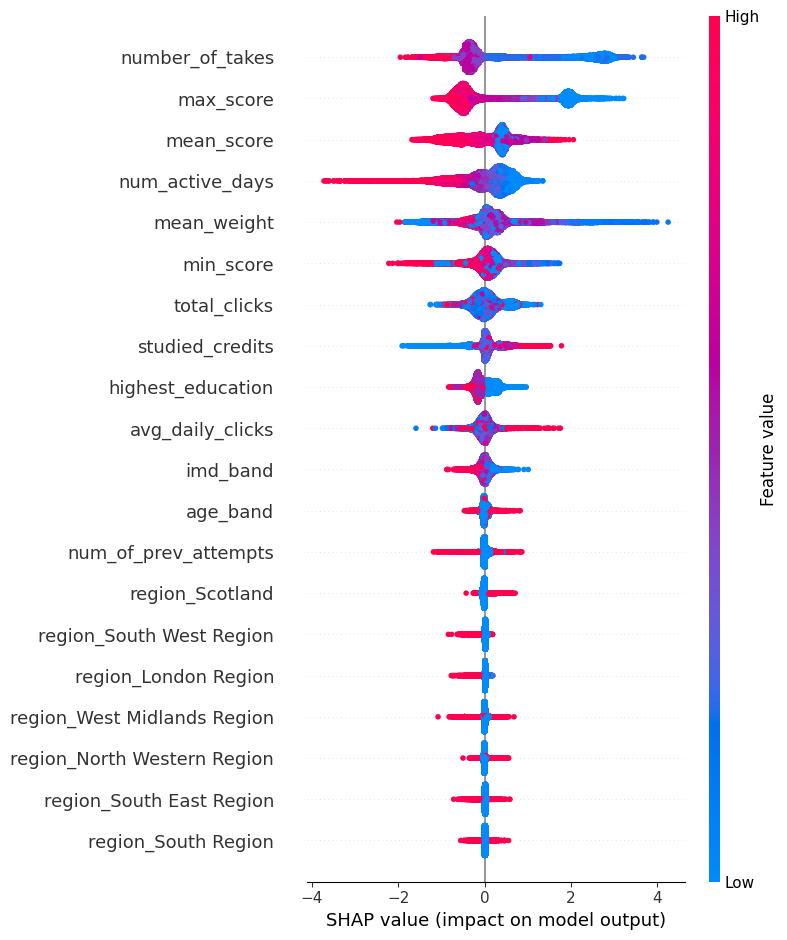

In [ ]:
shap.summary_plot(shap_values, X)

Okay, for study credits, students with low study credits were pushed towards save and sent to higher study credits were pushed towards at risk.

TAKING AN EXMAPLE ON HOW TO READ THE SUMMARY PLOT USING STUDIED_CREDITS. 
note the order of the features maarks their importance in predicting lables in the model

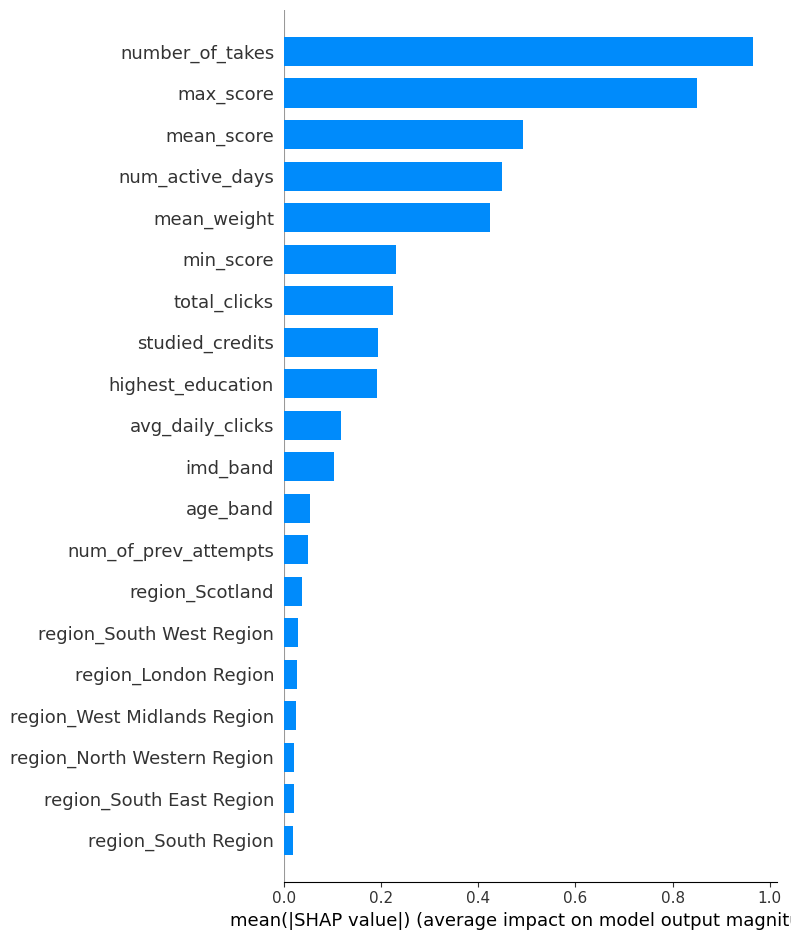

In [ ]:
shap.summary_plot(shap_values, X, plot_type= "bar")

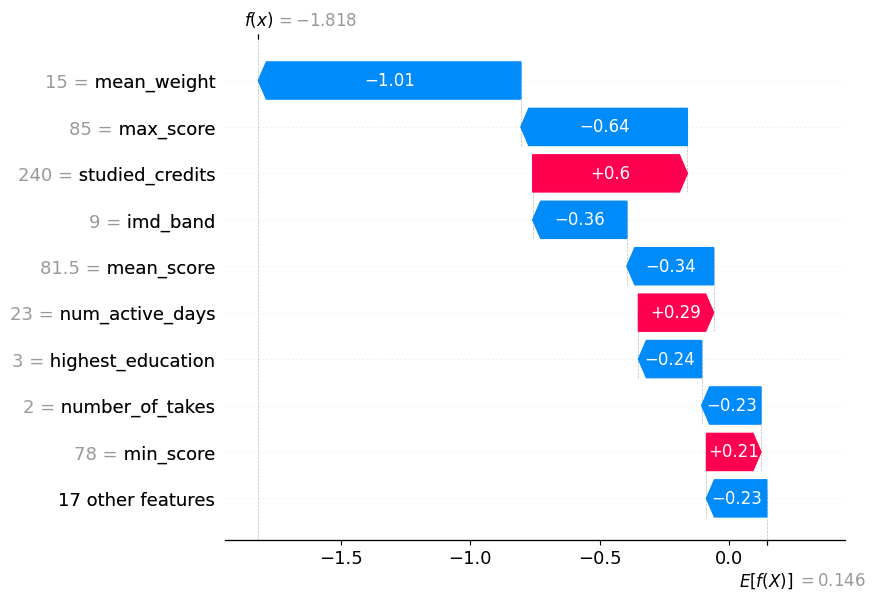

In [ ]:
# "Take the first student, and show me step by step how each feature moved their risk prediction from the average to their final score."

shap_explanation = explainer(X)
shap.plots.waterfall(shap_explanation[0])

"This student scored well (max_score=85, mean_score=81.5), has a good education level (3 = HE Qualification), and submitted 2 early assessments. These factors strongly push them toward Safe. Their high studied_credits (240) and few active days (23) slightly increase risk but not enough. Overall they are predicted Safe."

"Top 5 most important features: number_of_takes, max_score, mean_score, num_active_days, mean_weight. Assessment submission behaviour (number_of_takes) is the strongest predictor — more important than actual scores. Region features contribute almost no predictive value and will be considered for removal in v2."